# ABM: bicicletas compartidas y congestión vehicular

## Entorno, versiones y compatibilidad

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mesa

%matplotlib inline

try:
    from mesa.time import RandomActivation, SimultaneousActivation
    MESA2 = True
except ImportError:                 # Mesa >= 3.0: schedulers removidos
    MESA2 = False

### Parámetros del modelo

In [3]:
SEED = 42 # semilla maestra
N_COMMUTERS = 150 # numero de CommutterAgent
GRID_W, GRID_H = 20, 20 # cuadricula del centro urbano
UMBRAL_BICI = 3.0 # km, umbral de la regla de decision
DIST_MIN = 0.3 # km, cota inferior fisica para truncacion
CAP_CELDA = 2 # vehiculos por celda antes de considerarla congestionada

MU = np.array([8500.0, 6.5]) # (ingreso Q/mes, distancia km)
SIGMA = np.array([[4_000_000.0, -800.0],
                  [     -800.0,    4.0]])

print("mu    =", MU)
print("Sigma =\n", SIGMA)

mu    = [8.5e+03 6.5e+00]
Sigma =
 [[ 4.e+06 -8.e+02]
 [-8.e+02  4.e+00]]


# Task 1

## Task 1.1 Inicialización por Cholesky, Regla de Decisión y Modo de Scheduling

### a.

#### Fundamento Matemático

Sea $\boldsymbol{\Sigma}$ simétrica y definida positiva. Su descomposición de Cholesky es la factorización:
$$\boldsymbol{\Sigma} = \mathbf{L} \mathbf{L}^{\top}, \qquad \mathbf{L} \text{ triangular inferior}$$

Si $\mathbf{Z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_k)$ y definimos $\mathbf{X} = \boldsymbol{\mu} + \mathbf{Z}\mathbf{L}^{\top}$, entonces:
$$\mathbb{E}[\mathbf{X}] = \boldsymbol{\mu}, \qquad \operatorname{Cov}(\mathbf{X}) = \mathbf{L} \operatorname{Cov}(\mathbf{Z}) \mathbf{L}^{\top} = \mathbf{L} \mathbf{I} \mathbf{L}^{\top} = \mathbf{L} \mathbf{L}^{\top} = \boldsymbol{\Sigma}$$
por lo que $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$.

**Detalle de implementación:** Con `Z` almacenado por filas, de dimensión $(n, 2)$, la transformación matricial conforme es `X = mu + Z @ L.T`.

#### Correlación teórica esperada

$$\rho = \frac{\sigma_{12}}{\sigma_1 \sigma_2} = \frac{-800}{\sqrt{4{,}000{,}000}\cdot\sqrt{4}} = \frac{-800}{2000 \cdot 2} = -0.20$$


In [4]:
def sample_commuter_attributes(n, mu, sigma, rng, dist_min=DIST_MIN): # Genera n vectores X ~ N(mu, Sigma) por descomposicion de Cholesky.
    # Verificacion previa: Cholesky exige simetria y definicion positiva
    assert np.allclose(sigma, sigma.T), "Sigma no es simetrica"
    assert np.all(np.linalg.eigvals(sigma) > 0), "Sigma no es definida positiva"

    L = np.linalg.cholesky(sigma)          # Sigma = L @ L.T
    Z = rng.standard_normal((n, 2))        # Z ~ N(0, I)
    X = mu + Z @ L.T                       # X ~ N(mu, Sigma)

    # Truncacion: la normal asigna masa a distancias/ingresos negativos.
    # Se remuestrea el VECTOR COMPLETO invalido, no la componente aislada,
    # para no romper la estructura de dependencia entre atributos.
    n_resampled = 0
    invalid = (X[:, 1] < dist_min) | (X[:, 0] <= 0)
    while invalid.any():
        k = int(invalid.sum())
        n_resampled += k
        X[invalid] = mu + rng.standard_normal((k, 2)) @ L.T
        invalid = (X[:, 1] < dist_min) | (X[:, 0] <= 0)

    return X, L, n_resampled
    #X : ndarray (n, 2)   atributos (ingreso, distancia)
    #L : ndarray (2, 2)   factor de Cholesky, Sigma = L @ L.T
    #n_resampled : int    vectores remuestreados por truncacion

In [5]:
rng = np.random.default_rng(SEED)
X, L, n_res = sample_commuter_attributes(N_COMMUTERS, MU, SIGMA, rng)

print("Factor de Cholesky L:")
print(np.round(L, 6))
print("\nVerificacion  L @ L.T == Sigma :", np.allclose(L @ L.T, SIGMA))
print(f"Vectores remuestreados por truncacion (dist < {DIST_MIN} km): {n_res}")
print(f"\nForma de X: {X.shape}")
print("Primeras 5 filas (ingreso Q, distancia km):")
print(np.round(X[:5], 2))

Factor de Cholesky L:
[[ 2.000000e+03  0.000000e+00]
 [-4.000000e-01  1.959592e+00]]

Verificacion  L @ L.T == Sigma : True
Vectores remuestreados por truncacion (dist < 0.3 km): 0

Forma de X: (150, 2)
Primeras 5 filas (ingreso Q, distancia km):
[[9.10943e+03 4.34000e+00]
 [1.00009e+04 8.04000e+00]
 [4.59793e+03 4.73000e+00]
 [8.75568e+03 5.83000e+00]
 [8.46640e+03 4.84000e+00]]


#### Verificación de momentos muestrales

In [6]:
import math

def momentos(X, mu, sigma):
    filas = [
        ("media ingreso",    mu[0],                        X[:, 0].mean()),
        ("media distancia",  mu[1],                        X[:, 1].mean()),
        ("sd ingreso",       math.sqrt(sigma[0, 0]),       X[:, 0].std(ddof=1)),
        ("sd distancia",     math.sqrt(sigma[1, 1]),       X[:, 1].std(ddof=1)),
        ("covarianza",       sigma[0, 1],                  np.cov(X.T, ddof=1)[0, 1]),
    ]
    print(f"{'estadistico':<18}{'teorico':>14}{'muestral':>14}{'error rel.':>13}")
    print("-" * 59)
    for nombre, teo, mue in filas:
        err = abs(mue - teo) / abs(teo)
        print(f"{nombre:<18}{teo:>14.2f}{mue:>14.2f}{err:>12.1%}")

momentos(X, MU, SIGMA)

estadistico              teorico      muestral   error rel.
-----------------------------------------------------------
media ingreso            8500.00       8462.29        0.4%
media distancia             6.50          6.38        1.8%
sd ingreso               2000.00       1937.70        3.1%
sd distancia                2.00          1.76       12.0%
covarianza               -800.00       -473.37       40.8%


#### Correlación muestral e intervalo de confianza de Fisher

Para juzgar si $r$ es *consistente* con $\rho$ no basta compararlos: hace falta el error
de muestreo. Se usa la transformación de Fisher, que normaliza aproximadamente el
estadístico:

$$z = \operatorname{arctanh}(r), \qquad
\operatorname{SE}(z) = \frac{1}{\sqrt{n-3}}, \qquad
\text{IC}_{95\%}(\rho) = \tanh\!\left(z \pm 1.96\,\operatorname{SE}(z)\right)$$


In [7]:
def correlation_report(X, sigma): # Correlacion muestral, teorica e IC 95% por transformacion de Fisher.
    n = X.shape[0]
    r   = float(np.corrcoef(X[:, 0], X[:, 1])[0, 1])
    rho = float(sigma[0, 1] / np.sqrt(sigma[0, 0] * sigma[1, 1]))

    z  = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    return r, rho, (float(lo), float(hi))


r, rho, ci = correlation_report(X, SIGMA)

print(f"rho teorica     = {rho:+.4f}")
print(f"r  muestral     = {r:+.4f}")
print(f"IC 95% (Fisher) = [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"SE aproximado   =  {1/np.sqrt(N_COMMUTERS-3):.4f}")
print()
print(f"[OK] signo de r consistente con cov = {SIGMA[0,1]:.0f} < 0 : {r < 0}")
print(f"[OK] rho teorica contenida en el IC 95%                : {ci[0] <= rho <= ci[1]}")

rho teorica     = -0.2000
r  muestral     = -0.1388
IC 95% (Fisher) = [-0.2925, +0.0220]
SE aproximado   =  0.0825

[OK] signo de r consistente con cov = -800 < 0 : True
[OK] rho teorica contenida en el IC 95%                : True


#### Diagrama de dispersión de atributos generados

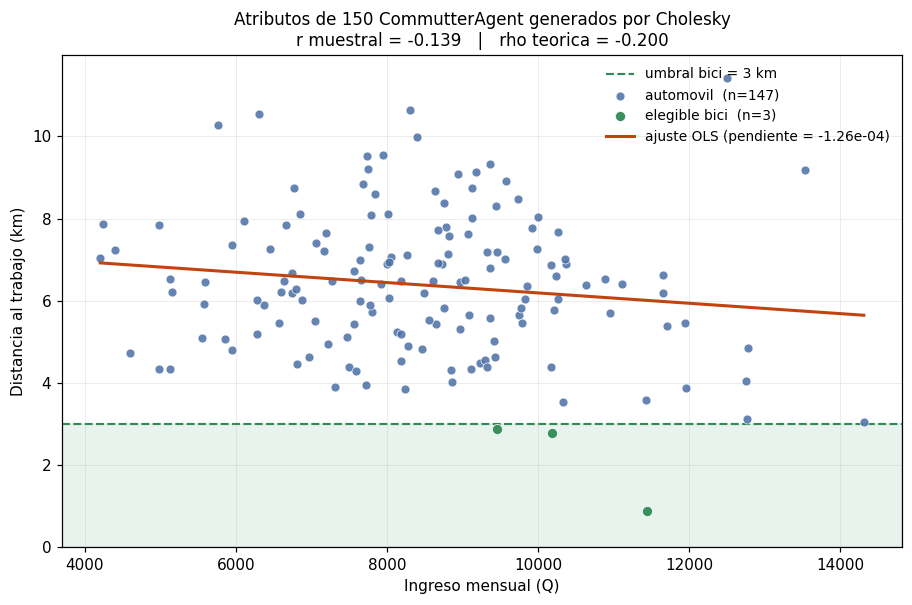

In [8]:
def plot_attributes(X, r, rho, umbral=UMBRAL_BICI):
    ing, dist = X[:, 0], X[:, 1]
    corta = dist <= umbral

    fig, ax = plt.subplots(figsize=(8.4, 5.6), dpi=110)

    ax.axhspan(0, umbral, color="#2e8b57", alpha=0.10, zorder=0)
    ax.axhline(umbral, color="#2e8b57", ls="--", lw=1.4, zorder=1,
               label=f"umbral bici = {umbral:.0f} km")

    ax.scatter(ing[~corta], dist[~corta], s=34, c="#4a6fa5", alpha=0.85,
               edgecolor="white", lw=0.5, zorder=3,
               label=f"automovil  (n={np.sum(~corta)})")
    ax.scatter(ing[corta], dist[corta], s=44, c="#2e8b57", alpha=0.95,
               edgecolor="white", lw=0.5, zorder=3,
               label=f"elegible bici  (n={np.sum(corta)})")

    b, a = np.polyfit(ing, dist, 1)
    xs = np.linspace(ing.min(), ing.max(), 100)
    ax.plot(xs, a + b * xs, color="#c1440e", lw=2, zorder=4,
            label=f"ajuste OLS (pendiente = {b:.2e})")

    ax.set_xlabel("Ingreso mensual (Q)")
    ax.set_ylabel("Distancia al trabajo (km)")
    ax.set_title(f"Atributos de {X.shape[0]} CommutterAgent generados por Cholesky\n"
                 f"r muestral = {r:+.3f}   |   rho teorica = {rho:+.3f}", fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_attributes(X, r, rho)
plt.show()